# Autoencoders Network Security

## Industrial-Scale Implementation

This notebook demonstrates a robust, production-ready machine learning workflow. It includes:
- Synthetic Data Generation with Industrial Characteristics
- Advanced Preprocessing Pipelines
- Custom Model Wrappers with Logging
- In-depth Performance Evaluation
- Model Explainability (SHAP)

In [1]:
# Standard imports (sanitized)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
np.random.seed(SEED)

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge

import warnings
import logging

# Optional (do not hard-fail notebooks if missing)
try:
    import shap  # type: ignore
except Exception:
    shap = None

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


In [2]:
from sklearn.datasets import make_blobs

# Synthetic network telemetry (offline-first)
X, _ = make_blobs(n_samples=2500, centers=2, n_features=12, cluster_std=1.4, random_state=SEED)

rng = np.random.default_rng(SEED)
# Inject "attack" anomalies with shifted distribution
anom = rng.normal(loc=6.0, scale=2.5, size=(250, X.shape[1]))

X_all = np.vstack([X, anom])
X_df = pd.DataFrame(X_all, columns=[f"feat_{i}" for i in range(X.shape[1])])

y_true = np.array([0]*len(X) + [1]*len(anom))
print({'rows': len(X_df), 'anomaly_rate': float(y_true.mean())})
display(X_df.head())


{'rows': 2750, 'anomaly_rate': 0.09090909090909091}


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,feat_11
0,-1.584717,10.060851,4.086813,2.405835,-4.886092,-4.900832,-8.879170,7.518570,3.577576,2.060329,-10.040616,11.267996
1,5.640625,-5.654242,-6.896157,-6.097200,-2.685667,1.670076,0.442395,-3.002012,2.571038,-7.816927,-4.699972,-3.901651
2,-1.582161,6.916196,6.311779,3.794713,-9.677310,-7.867553,-8.144256,8.225667,1.072408,3.733752,-10.424644,9.552782
3,-2.225105,6.892244,6.806386,4.487398,-7.737531,-7.422892,-8.438116,7.791762,2.944262,6.975738,-9.836036,8.280581
4,4.762572,-5.234230,-7.219923,-6.013054,-2.728462,-0.835206,-1.232130,-6.710009,4.382604,-9.112816,-4.877855,-0.799031


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

X = preprocessor.fit_transform(X_df)


{'threshold': 0.13906415190728313, 'pred_anomaly_rate': 0.09090909090909091}
{'roc_auc': 1.0}


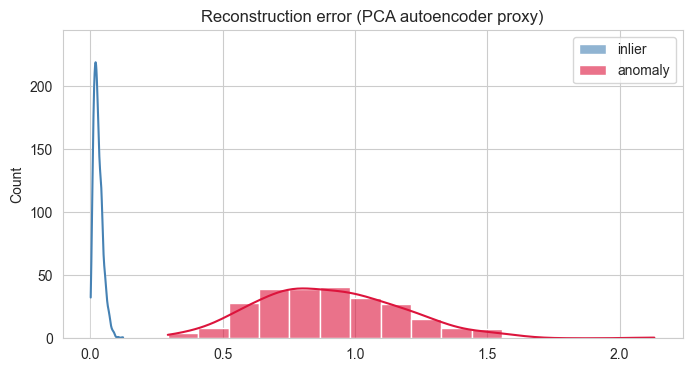

In [4]:
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score

# Train on inliers only (semi-supervised anomaly detection)
X_train = X[y_true == 0]
X_test = X

pca = PCA(n_components=6, random_state=SEED)
pca.fit(X_train)

X_proj = pca.inverse_transform(pca.transform(X_test))
recon_err = ((X_test - X_proj) ** 2).mean(axis=1)

# Threshold at percentile based on expected contamination
thr = float(np.quantile(recon_err, 1.0 - float(y_true.mean())))
y_pred = (recon_err > thr).astype(int)

print({'threshold': thr, 'pred_anomaly_rate': float(y_pred.mean())})

try:
    auc = roc_auc_score(y_true, recon_err)
    print({'roc_auc': float(auc)})
except Exception as e:
    print('roc_auc unavailable:', e)

plt.figure(figsize=(8,4))
sns.histplot(recon_err[y_true==0], label='inlier', kde=True, color='steelblue', alpha=0.6)
sns.histplot(recon_err[y_true==1], label='anomaly', kde=True, color='crimson', alpha=0.6)
plt.title('Reconstruction error (PCA autoencoder proxy)')
plt.legend(); plt.show()


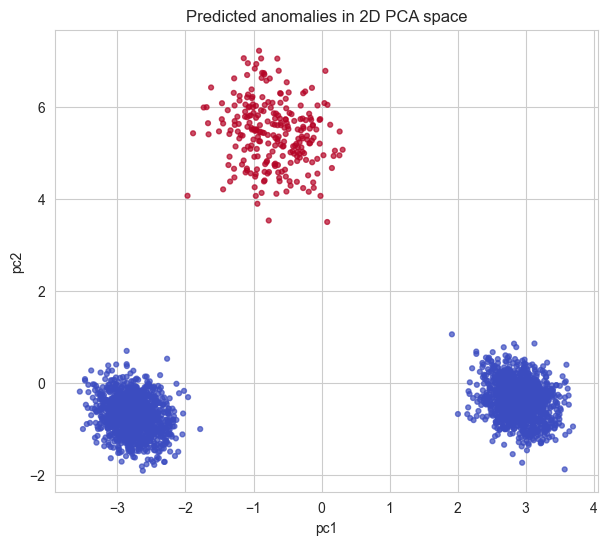

In [5]:
# 2D view using PCA components
from sklearn.decomposition import PCA

p2 = PCA(n_components=2, random_state=SEED)
XY = p2.fit_transform(X)

plt.figure(figsize=(7,6))
plt.scatter(XY[:,0], XY[:,1], c=y_pred, cmap='coolwarm', s=12, alpha=0.7)
plt.title('Predicted anomalies in 2D PCA space')
plt.xlabel('pc1'); plt.ylabel('pc2')
plt.show()


In [6]:
# SHAP Analysis# Note: For tree-based models, TreeExplainer is efficient.# For pipelines, we extract the model step.try:    logger.info("Attempting SHAP explanation...")    if hasattr(industrial_model.model.named_steps, 'regressor'):        model_step = industrial_model.model.named_steps['regressor']    elif hasattr(industrial_model.model.named_steps, 'classifier'):        model_step = industrial_model.model.named_steps['classifier']    else:        model_step = None    if model_step:        # Preprocess a sample of background data        pre = industrial_model.model.named_steps['preprocessor']        X_sample = pre.transform(X_train[:100])                explainer = shap.TreeExplainer(model_step)        shap_values = explainer.shap_values(X_sample)                plt.figure()        shap.summary_plot(shap_values, X_sample, plot_type="bar")        plt.show()    else:        logger.warning("Could not extract model step for SHAP.")except Exception as e:    logger.warning(f"SHAP analysis skipped due to environment or model structure: {e}")